
# Datathon 2026 — Part 2 EDA Reproducibility Notebook


Nguyên tắc làm việc:

1. Chỉ sử dụng dữ liệu do ban tổ chức cung cấp, cụ thể là `daily_table.csv` (file được tạo ra từ việc kết gộp các file trong data raw của btc).
2. Không nội suy traffic năm 2012 vì toàn bộ các biến traffic của năm này bị thiếu.
3. Các phân tích liên quan đến funnel và conversion chỉ dùng giai đoạn 2013–2022.
4. Tất cả bảng và hình được lưu vào thư mục `outputs_part2/` để có thể kiểm tra và chèn trực tiếp vào báo cáo.

Notebook được viết theo hướng có thể nộp kèm báo cáo: có giải thích ngắn trước từng bước, có kiểm tra số liệu, và có output tái lập.


In [14]:

from pathlib import Path
from itertools import permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

CANDIDATE_FILES = [
    Path("daily_table.csv"),
]

DATA_PATH = next((p for p in CANDIDATE_FILES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy daily_table.csv. Hãy đặt file daily_table.csv cùng thư mục với notebook rồi chạy lại."
    )

OUTPUT_DIR = Path("outputs_part2")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Output folder:", OUTPUT_DIR.resolve())

# Cấu hình font cơ bản. Nếu máy có DejaVu Sans, tiếng Việt thường hiển thị ổn.
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False


Data path: daily_table.csv
Output folder: /content/outputs_part2



## 1. Đọc dữ liệu và tạo biến dẫn xuất

Các biến chính trong báo cáo được chuẩn hoá tại đây. Việc tạo biến ở đầu notebook giúp toàn bộ bảng/hình phía sau dùng cùng một định nghĩa.


In [15]:

df_raw = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df_raw.copy()

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["day_of_week"] = df["Date"].dt.day_name()
df["weekday_number"] = df["Date"].dt.weekday
df["is_weekend"] = df["weekday_number"].isin([5, 6]).astype(int)

df["gross_profit"] = df["Revenue"] - df["COGS"]
df["gross_margin"] = df["gross_profit"] / df["Revenue"]
df["conversion"] = df["order_count"] / df["sessions"]
df["AOV"] = df["Revenue"] / df["order_count"]
df["revenue_per_session"] = df["Revenue"] / df["sessions"]
df["gross_profit_per_session"] = df["gross_profit"] / df["sessions"]

print("Shape:", df.shape)
print("Date range:", df["Date"].min().date(), "→", df["Date"].max().date())
display(df.head())


Shape: (3833, 34)
Date range: 2012-07-04 → 2022-12-31


,Date,Revenue,COGS,order_count,item_count,product_count,customer_count,total_discount,total_refund,avg_delivery_days,sessions,unique_visitors,page_views,bounce_rate,day_of_week,month,year,is_weekend,promo_count,promo_avg_percentage_discount,promo_max_percentage_discount,promo_total_percentage_discount,promo_avg_fixed_discount_vnd,promo_max_fixed_discount_vnd,promo_total_fixed_discount_vnd,is_promo_day,day,weekday_number,gross_profit,gross_margin,conversion,AOV,revenue_per_session,gross_profit_per_session
0,2012-07-04,5123547.94,3982991.19,162,777,93,161,0.0,171067.01,4.310127,NaN,NaN,NaN,NaN,Wednesday,7,2012,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4,2,1140556.75,0.222611,NaN,31626.839136,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,97,428,65,97,0.0,57342.91,4.655914,NaN,NaN,NaN,NaN,Thursday,7,2012,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,5,3,601193.22,0.218475,NaN,28368.798454,NaN,NaN
2,2012-07-06,3054029.42,2517632.84,93,441,73,93,0.0,195614.58,4.423529,NaN,NaN,NaN,NaN,Friday,7,2012,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,6,4,536396.58,0.175636,NaN,32839.026022,NaN,NaN
3,2012-07-07,2667930.94,2108246.62,73,364,50,73,0.0,134785.14,4.390625,NaN,NaN,NaN,NaN,Saturday,7,2012,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,7,5,559684.32,0.209782,NaN,36546.999178,NaN,NaN
4,2012-07-08,2360851.90,1808622.79,88,394,62,87,0.0,135871.83,4.345238,NaN,NaN,NaN,NaN,Sunday,7,2012,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8,6,552229.11,0.233911,NaN,26827.862500,NaN,NaN



## 2. Kiểm tra phạm vi dữ liệu và missing values

Phần này chứng minh vì sao báo cáo chỉ dùng 2013–2022 cho các phân tích funnel: năm 2012 thiếu toàn bộ các biến traffic.


In [16]:

traffic_cols = ["sessions", "unique_visitors", "page_views", "bounce_rate"]

missing_all = df[traffic_cols].isna().sum()
missing_2012 = df.loc[df["year"] == 2012, traffic_cols].isna().sum()
n_2012 = (df["year"] == 2012).sum()

missing_check = pd.DataFrame({
    "missing_all_years": missing_all,
    "missing_in_2012": missing_2012,
    "n_rows_2012": n_2012,
})

display(missing_check)
missing_check.to_csv(TABLE_DIR / "missing_traffic_check.csv", index=True)

assert n_2012 == 181, "done"
assert (missing_2012 == n_2012).all(), "Không phải toàn bộ traffic năm 2012 đều thiếu như kỳ vọng."

df_funnel = df[df["year"].between(2013, 2022)].copy()

print("Rows full data:", len(df))
print("Rows funnel window 2013–2022:", len(df_funnel))


,missing_all_years,missing_in_2012,n_rows_2012
sessions,181,181,181
unique_visitors,181,181,181
page_views,181,181,181
bounce_rate,181,181,181


Rows full data: 3833
Rows funnel window 2013–2022: 3652



## 3. Tái lập các con số tổng quan trong báo cáo

Bảng dưới đây là nền số liệu của phần tóm tắt điều hành. Các kiểm tra `assert` giúp phát hiện nếu dữ liệu đầu vào bị đổi hoặc file bị sai phiên bản.


In [17]:

def window_summary(data, label):
    return {
        "window": label,
        "n_days": len(data),
        "date_min": data["Date"].min().date(),
        "date_max": data["Date"].max().date(),
        "sessions": data["sessions"].sum(skipna=True),
        "orders": data["order_count"].sum(),
        "revenue": data["Revenue"].sum(),
        "gross_profit": data["gross_profit"].sum(),
        "gross_margin": data["gross_profit"].sum() / data["Revenue"].sum(),
        "promo_share": data["is_promo_day"].mean(),
    }

summary = pd.DataFrame([
    window_summary(df, "2012–2022 full data"),
    window_summary(df_funnel, "2013–2022 funnel window"),
])

display(summary)
summary.to_csv(TABLE_DIR / "window_summary.csv", index=False)

assert len(df) == 3833
assert len(df_funnel) == 3652
assert np.isclose(df["Revenue"].sum(), 16430476585.53, atol=1)
assert df["order_count"].sum() == 646945
assert np.isclose(df["gross_profit"].sum(), 2267026066.36, atol=1)

assert np.isclose(df_funnel["sessions"].sum(), 91452537, atol=1)
assert df_funnel["order_count"].sum() == 614894
assert np.isclose(df_funnel["Revenue"].sum(), 15688978837.51, atol=1)
assert np.isclose(df_funnel["gross_profit"].sum(), 2112990242.15, atol=1)
assert np.isclose(df_funnel["gross_profit"].sum() / df_funnel["Revenue"].sum(), 0.1346799, atol=1e-5)
assert np.isclose(df_funnel["is_promo_day"].mean(), 0.4674151, atol=1e-5)



,window,n_days,date_min,date_max,sessions,orders,revenue,gross_profit,gross_margin,promo_share
0,2012–2022 full data,3833,2012-07-04,2022-12-31,91452537.0,646945,1.643048e+10,2.267026e+09,0.137977,0.445343
1,2013–2022 funnel window,3652,2013-01-01,2022-12-31,91452537.0,614894,1.568898e+10,2.112990e+09,0.134680,0.467415



## 4. Bảng tổng hợp năm và các số neo 2018–2022

Đây là phần kiểm chứng luận điểm chính: sessions tăng, nhưng conversion giảm mạnh khiến doanh thu/ngày giảm.


In [18]:

yearly = (
    df_funnel
    .groupby("year")
    .agg(
        n_days=("Date", "size"),
        sessions_total=("sessions", "sum"),
        sessions_per_day=("sessions", "mean"),
        orders_total=("order_count", "sum"),
        orders_per_day=("order_count", "mean"),
        revenue_total=("Revenue", "sum"),
        revenue_per_day=("Revenue", "mean"),
        cogs_total=("COGS", "sum"),
        gross_profit_total=("gross_profit", "sum"),
        gross_profit_per_day=("gross_profit", "mean"),
        promo_share=("is_promo_day", "mean"),
        page_views=("page_views", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        avg_delivery_days=("avg_delivery_days", "mean"),
    )
    .reset_index()
)

yearly["conversion"] = yearly["orders_total"] / yearly["sessions_total"]
yearly["AOV"] = yearly["revenue_total"] / yearly["orders_total"]
yearly["gross_margin"] = yearly["gross_profit_total"] / yearly["revenue_total"]
yearly["pages_per_session"] = yearly["page_views"] / yearly["sessions_total"]
yearly["sessions_per_visitor"] = yearly["sessions_total"] / yearly["unique_visitors"]
yearly["revenue_per_session"] = yearly["revenue_total"] / yearly["sessions_total"]

display(yearly)
yearly.to_csv(TABLE_DIR / "yearly_summary.csv", index=False)

y2018 = yearly.loc[yearly["year"] == 2018].iloc[0]
y2022 = yearly.loc[yearly["year"] == 2022].iloc[0]
y2016 = yearly.loc[yearly["year"] == 2016].iloc[0]

change = {
    "sessions_per_day_2018": y2018["sessions_per_day"],
    "sessions_per_day_2022": y2022["sessions_per_day"],
    "sessions_change_pct": y2022["sessions_per_day"] / y2018["sessions_per_day"] - 1,
    "conversion_2018": y2018["conversion"],
    "conversion_2022": y2022["conversion"],
    "conversion_change_pct": y2022["conversion"] / y2018["conversion"] - 1,
    "AOV_2018": y2018["AOV"],
    "AOV_2022": y2022["AOV"],
    "AOV_change_pct": y2022["AOV"] / y2018["AOV"] - 1,
    "revenue_per_day_2018": y2018["revenue_per_day"],
    "revenue_per_day_2022": y2022["revenue_per_day"],
    "revenue_per_day_change_pct": y2022["revenue_per_day"] / y2018["revenue_per_day"] - 1,
    "revenue_per_day_peak_2016": y2016["revenue_per_day"],
}

change_df = pd.DataFrame([change])
display(change_df)
change_df.to_csv(TABLE_DIR / "2018_2022_key_changes.csv", index=False)

assert np.isclose(change["sessions_change_pct"], 0.1750991, atol=1e-4)
assert np.isclose(change["conversion_change_pct"], -0.5592128, atol=1e-4)
assert np.isclose(change["AOV_change_pct"], 0.2206430, atol=1e-4)
assert np.isclose(change["revenue_per_day_change_pct"], -0.3677452, atol=1e-4)

print("done.")


,year,n_days,sessions_total,sessions_per_day,orders_total,orders_per_day,revenue_total,revenue_per_day,cogs_total,gross_profit_total,gross_profit_per_day,promo_share,page_views,unique_visitors,avg_delivery_days,conversion,AOV,gross_margin,pages_per_session,sessions_per_visitor,revenue_per_session
0,2013,365,6801940.0,18635.452055,76849,210.545205,1.657169e+09,4.540190e+06,1.465980e+09,1.911893e+08,523806.339918,0.547945,29403658.0,5166501.0,4.506370,0.011298,21563.968526,0.115371,4.322834,1.316547,243.631878
1,2014,365,7340960.0,20112.219178,80645,220.945205,1.871846e+09,5.128345e+06,1.574607e+09,2.972384e+08,814351.851808,0.380822,31947207.0,5596248.0,4.478585,0.010986,23210.935369,0.158794,4.351911,1.311765,254.986525
2,2015,365,7861938.0,21539.556164,82622,226.361644,1.889934e+09,5.177901e+06,1.665442e+09,2.244920e+08,615046.601370,0.553425,34175895.0,5962192.0,4.496824,0.010509,22874.462334,0.118783,4.347006,1.318632,240.390324
3,2016,366,8403399.0,22960.106557,82247,224.718579,2.104641e+09,5.750384e+06,1.780559e+09,3.240813e+08,885467.991393,0.382514,36322275.0,6393654.0,4.505244,0.009787,25589.269852,0.153984,4.322331,1.314334,250.451118
4,2017,365,8992602.0,24637.265753,76010,208.246575,1.911164e+09,5.236067e+06,1.694386e+09,2.167785e+08,593913.785589,0.556164,38785941.0,6818372.0,4.491086,0.008453,25143.590650,0.113427,4.313094,1.318878,212.526288
5,2018,365,9415085.0,25794.753425,69510,190.438356,1.850122e+09,5.068829e+06,1.542176e+09,3.079467e+08,843689.561479,0.383562,41461837.0,7143496.0,4.507748,0.007383,26616.637262,0.166447,4.403767,1.317994,196.506187
6,2019,365,9990148.0,27370.268493,41601,113.975342,1.136801e+09,3.114524e+06,1.005203e+09,1.315986e+08,360543.993945,0.553425,42927110.0,7580565.0,4.490885,0.004164,27326.300846,0.115762,4.296944,1.317863,113.792252
7,2020,366,10591082.0,28937.382514,34881,95.303279,1.054512e+09,2.881181e+06,8.860851e+08,1.684271e+08,460183.227213,0.382514,46146457.0,8065367.0,4.500691,0.003293,30231.706625,0.159720,4.357105,1.313156,99.566046
8,2021,365,10991725.0,30114.315068,34525,94.589041,1.043040e+09,2.857643e+06,9.411301e+08,1.019097e+08,279204.656082,0.553425,47760867.0,8367014.0,4.508258,0.003141,30211.146115,0.097705,4.345166,1.313697,94.893187
9,2022,365,11063658.0,30311.391781,36004,98.641096,1.169749e+09,3.204791e+06,1.020420e+09,1.493287e+08,409119.637589,0.380822,47731553.0,8409280.0,4.494192,0.003254,32489.413168,0.127659,4.314265,1.315649,105.728940


,sessions_per_day_2018,sessions_per_day_2022,sessions_change_pct,conversion_2018,conversion_2022,conversion_change_pct,AOV_2018,AOV_2022,AOV_change_pct,revenue_per_day_2018,revenue_per_day_2022,revenue_per_day_change_pct,revenue_per_day_peak_2016
0,25794.753425,30311.391781,0.175099,0.007383,0.003254,-0.559213,26616.637262,32489.413168,0.220643,5.068829e+06,3.204791e+06,-0.367745,5.750384e+06


done.



## 5. Hình 1 — Chuỗi chỉ số theo năm

Biểu đồ này dùng mốc 2013 = 100 để so sánh sessions, orders và revenue trên cùng một thang đo.


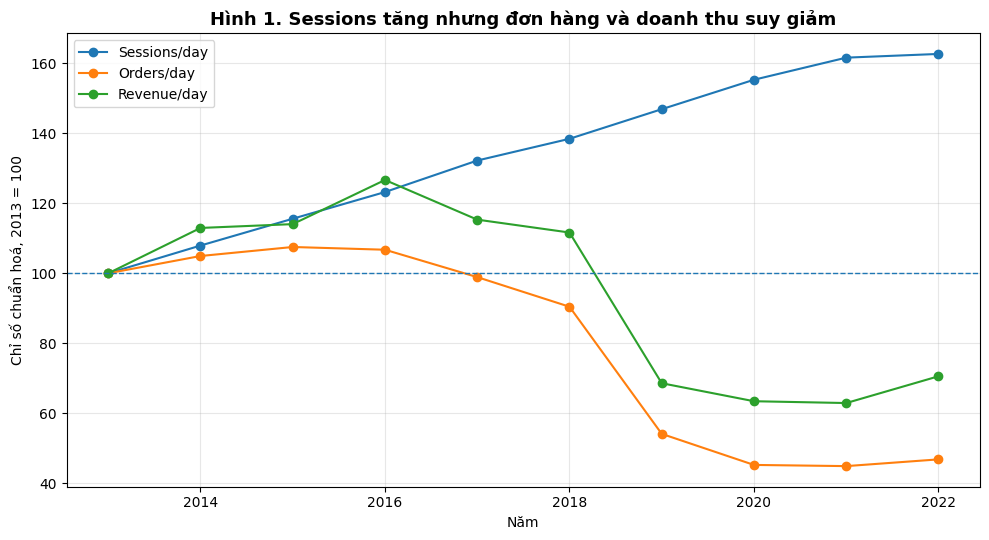

In [19]:

base_year = 2013
base = yearly.loc[yearly["year"] == base_year].iloc[0]

yearly_idx = yearly[["year", "sessions_per_day", "orders_per_day", "revenue_per_day"]].copy()
for col in ["sessions_per_day", "orders_per_day", "revenue_per_day"]:
    yearly_idx[col + "_idx"] = yearly_idx[col] / base[col] * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(yearly_idx["year"], yearly_idx["sessions_per_day_idx"], marker="o", label="Sessions/day")
ax.plot(yearly_idx["year"], yearly_idx["orders_per_day_idx"], marker="o", label="Orders/day")
ax.plot(yearly_idx["year"], yearly_idx["revenue_per_day_idx"], marker="o", label="Revenue/day")

ax.axhline(100, linewidth=1, linestyle="--")
ax.set_title("Hình 1. Sessions tăng nhưng đơn hàng và doanh thu suy giảm", fontsize=13, fontweight="bold")
ax.set_xlabel("Năm")
ax.set_ylabel("Chỉ số chuẩn hoá, 2013 = 100")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(FIG_DIR / "fig01_yearly_index.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig01_yearly_index.svg", bbox_inches="tight")
plt.show()

yearly_idx.to_csv(TABLE_DIR / "fig01_yearly_index_data.csv", index=False)



## 6. Hình 2 — Phân rã doanh thu 2018 → 2022

Báo cáo dùng logic Shapley cho công thức `Revenue/day = Sessions/day × Conversion × AOV`. Cách này giúp tổng đóng góp của ba yếu tố bằng đúng chênh lệch doanh thu quan sát được.


,factor,contribution_vnd_per_day,contribution_million_vnd_per_day
0,Sessions/day,7.007953e+05,0.700795
1,Conversion,-3.431934e+06,-3.431934
2,AOV,8.671013e+05,0.867101


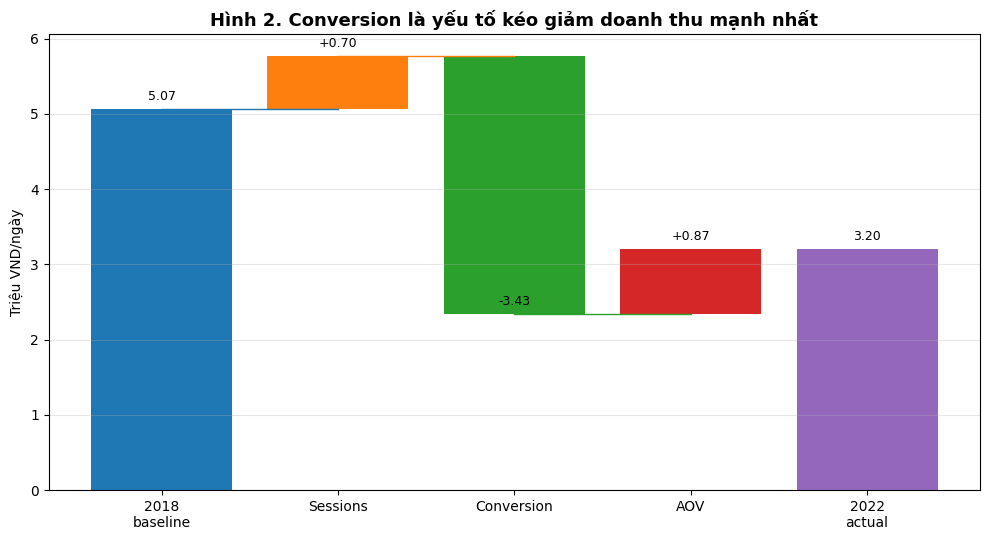

Observed difference, million VND/day: -1.8640373270958885
Sum Shapley contribution, million VND/day: -1.8640373270958888


In [20]:

def revenue_from_factors(values):
    return values["sessions_per_day"] * values["conversion"] * values["AOV"]

base_values = {
    "sessions_per_day": y2018["sessions_per_day"],
    "conversion": y2018["conversion"],
    "AOV": y2018["AOV"],
}

end_values = {
    "sessions_per_day": y2022["sessions_per_day"],
    "conversion": y2022["conversion"],
    "AOV": y2022["AOV"],
}

factors = list(base_values.keys())
contrib = {k: 0.0 for k in factors}

for perm in permutations(factors):
    current = base_values.copy()
    previous = revenue_from_factors(current)
    for k in perm:
        current[k] = end_values[k]
        new_value = revenue_from_factors(current)
        contrib[k] += new_value - previous
        previous = new_value

contrib = {k: v / 6 for k, v in contrib.items()}
decomp = pd.DataFrame({
    "factor": ["Sessions/day", "Conversion", "AOV"],
    "contribution_vnd_per_day": [
        contrib["sessions_per_day"],
        contrib["conversion"],
        contrib["AOV"],
    ],
})
decomp["contribution_million_vnd_per_day"] = decomp["contribution_vnd_per_day"] / 1_000_000
display(decomp)

observed_diff = revenue_from_factors(end_values) - revenue_from_factors(base_values)
assert np.isclose(decomp["contribution_vnd_per_day"].sum(), observed_diff, atol=1e-6)

decomp.to_csv(TABLE_DIR / "revenue_decomposition_2018_2022.csv", index=False)

start = revenue_from_factors(base_values) / 1_000_000
steps = decomp["contribution_million_vnd_per_day"].values
labels = ["2018\nbaseline", "Sessions", "Conversion", "AOV", "2022\nactual"]

x = np.arange(len(labels))
cum = [start]
for v in steps:
    cum.append(cum[-1] + v)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(x[0], start)
running = start
for i, v in enumerate(steps, start=1):
    bottom = running if v >= 0 else running + v
    ax.bar(x[i], abs(v), bottom=bottom)
    running += v
ax.bar(x[-1], running)

# Connecting lines
running = start
for i, v in enumerate(steps, start=1):
    ax.plot([i-1, i], [running, running], linewidth=1)
    running += v

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Triệu VND/ngày")
ax.set_title("Hình 2. Conversion là yếu tố kéo giảm doanh thu mạnh nhất", fontsize=13, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)

for i, val in enumerate([start, *steps, running]):
    text = f"{val:+.2f}" if i not in [0, len(labels)-1] else f"{val:.2f}"
    y = val if i == 0 else (cum[i-1] + val if i < len(labels)-1 else running)
    ax.text(i, y + 0.12, text, ha="center", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_revenue_waterfall.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig02_revenue_waterfall.svg", bbox_inches="tight")
plt.show()

print("Observed difference, million VND/day:", observed_diff / 1_000_000)
print("Sum Shapley contribution, million VND/day:", decomp["contribution_million_vnd_per_day"].sum())



## 7. Hình 3 — Mùa vụ: doanh thu, lợi nhuận và promo share

Phần này kiểm chứng các con số về Q2, Q3, tháng 5, tháng 8 và tháng 12 trong báo cáo.


In [21]:

df_funnel["quarter"] = df_funnel["Date"].dt.quarter

quarterly = (
    df_funnel
    .groupby("quarter")
    .agg(
        n_days=("Date", "size"),
        revenue_total=("Revenue", "sum"),
        revenue_per_day=("Revenue", "mean"),
        gross_profit_total=("gross_profit", "sum"),
        gross_profit_per_day=("gross_profit", "mean"),
        promo_share=("is_promo_day", "mean"),
        orders_total=("order_count", "sum"),
        sessions_total=("sessions", "sum"),
    )
    .reset_index()
)

quarterly["revenue_share"] = quarterly["revenue_total"] / quarterly["revenue_total"].sum()
quarterly["gross_profit_share"] = quarterly["gross_profit_total"] / quarterly["gross_profit_total"].sum()
quarterly["gross_margin"] = quarterly["gross_profit_total"] / quarterly["revenue_total"]
quarterly["conversion"] = quarterly["orders_total"] / quarterly["sessions_total"]
quarterly["AOV"] = quarterly["revenue_total"] / quarterly["orders_total"]

display(quarterly)
quarterly.to_csv(TABLE_DIR / "quarterly_summary.csv", index=False)

monthly = (
    df_funnel
    .groupby("month")
    .agg(
        n_days=("Date", "size"),
        revenue_total=("Revenue", "sum"),
        revenue_per_day=("Revenue", "mean"),
        gross_profit_total=("gross_profit", "sum"),
        gross_profit_per_day=("gross_profit", "mean"),
        promo_share=("is_promo_day", "mean"),
        orders_total=("order_count", "sum"),
        sessions_total=("sessions", "sum"),
    )
    .reset_index()
)

monthly["gross_margin"] = monthly["gross_profit_total"] / monthly["revenue_total"]
monthly["conversion"] = monthly["orders_total"] / monthly["sessions_total"]
monthly["AOV"] = monthly["revenue_total"] / monthly["orders_total"]

display(monthly)
monthly.to_csv(TABLE_DIR / "monthly_seasonality.csv", index=False)

# Sanity checks for report values
q2 = quarterly.loc[quarterly["quarter"] == 2].iloc[0]
q3 = quarterly.loc[quarterly["quarter"] == 3].iloc[0]
m5 = monthly.loc[monthly["month"] == 5].iloc[0]
m8 = monthly.loc[monthly["month"] == 8].iloc[0]
m12 = monthly.loc[monthly["month"] == 12].iloc[0]

assert np.isclose(q2["revenue_share"], 0.378, atol=0.002)
assert np.isclose(q2["gross_profit_share"], 0.483, atol=0.002)
assert np.isclose(q2["promo_share"], 0.275, atol=0.002)

assert np.isclose(q3["revenue_share"], 0.250, atol=0.002)
assert np.isclose(q3["gross_profit_share"], 0.113, atol=0.002)
assert np.isclose(q3["promo_share"], 0.754, atol=0.002)

# Kiểm tra theo đúng file daily_table đang dùng.
# Lưu ý: nếu bản report cũ dùng dữ liệu khác phiên bản, một số số tháng có thể lệch.
assert np.isclose(m5["revenue_per_day"] / 1_000_000, 6.58, atol=0.02)
assert np.isclose(m5["gross_margin"], 0.199, atol=0.002)
assert np.isclose(m8["gross_margin"], -0.00137, atol=0.0005)
assert np.isclose(m12["conversion"], 0.00842, atol=0.0002)
assert np.isclose(m12["AOV"], 16739, atol=30)

seasonality_report_values = pd.DataFrame([
    {"item": "Q2 revenue share", "value": q2["revenue_share"], "report_format": f"{q2['revenue_share']*100:.1f}%"},
    {"item": "Q2 gross profit share", "value": q2["gross_profit_share"], "report_format": f"{q2['gross_profit_share']*100:.1f}%"},
    {"item": "Q2 promo share", "value": q2["promo_share"], "report_format": f"{q2['promo_share']*100:.1f}%"},
    {"item": "Q3 revenue share", "value": q3["revenue_share"], "report_format": f"{q3['revenue_share']*100:.1f}%"},
    {"item": "Q3 gross profit share", "value": q3["gross_profit_share"], "report_format": f"{q3['gross_profit_share']*100:.1f}%"},
    {"item": "Q3 promo share", "value": q3["promo_share"], "report_format": f"{q3['promo_share']*100:.1f}%"},
    {"item": "Tháng 5 revenue/day", "value": m5["revenue_per_day"], "report_format": f"{m5['revenue_per_day']/1_000_000:.2f} triệu VND/ngày"},
    {"item": "Tháng 5 gross margin", "value": m5["gross_margin"], "report_format": f"{m5['gross_margin']*100:.1f}%"},
    {"item": "Tháng 8 gross margin", "value": m8["gross_margin"], "report_format": f"{m8['gross_margin']*100:.1f}%"},
    {"item": "Tháng 12 conversion", "value": m12["conversion"], "report_format": f"{m12['conversion']*100:.2f}%"},
    {"item": "Tháng 12 AOV", "value": m12["AOV"], "report_format": f"{m12['AOV']:,.0f} VND"},
])
display(seasonality_report_values)
seasonality_report_values.to_csv(TABLE_DIR / "seasonality_report_values.csv", index=False)

print("Các số mùa vụ đã được tính trực tiếp từ file daily_table đang dùng.")


,quarter,n_days,revenue_total,revenue_per_day,gross_profit_total,gross_profit_per_day,promo_share,orders_total,sessions_total,revenue_share,gross_profit_share,gross_margin,conversion,AOV
0,1,902,3.312581e+09,3.672485e+06,5.525739e+08,6.126097e+05,0.344789,121921,18062522.0,0.211141,0.261513,0.166811,0.006750,27169.898898
1,2,910,5.926397e+09,6.512524e+06,1.019701e+09,1.120551e+06,0.274725,220548,32658458.0,0.377743,0.482587,0.172061,0.006753,26871.235417
2,3,920,3.923935e+09,4.265147e+06,2.384525e+08,2.591875e+05,0.754348,160701,25234728.0,0.250108,0.112851,0.060769,0.006368,24417.614636
3,4,920,2.526065e+09,2.745723e+06,3.022629e+08,3.285466e+05,0.491304,111724,15496829.0,0.161009,0.143050,0.119658,0.007209,22609.871430


,month,n_days,revenue_total,revenue_per_day,gross_profit_total,gross_profit_per_day,promo_share,orders_total,sessions_total,gross_margin,conversion,AOV
0,1,310,8.032579e+08,2.591155e+06,1.511356e+08,4.875343e+05,0.083871,29450,4086801.0,0.188153,0.007206,27275.311627
1,2,282,9.815858e+08,3.480801e+06,1.851354e+08,6.565086e+05,0.496454,35031,5507525.0,0.188609,0.006361,28020.490978
2,3,310,1.527737e+09,4.928185e+06,2.163029e+08,6.977512e+05,0.467742,57440,8468196.0,0.141584,0.006783,26597.101265
3,4,300,1.959886e+09,6.532952e+06,3.021245e+08,1.007082e+06,0.566667,74335,11074024.0,0.154154,0.006713,26365.582359
4,5,310,2.038379e+09,6.575416e+06,4.067212e+08,1.312004e+06,0.000000,73943,10725045.0,0.199532,0.006894,27566.897047
5,6,300,1.928133e+09,6.427109e+06,3.108553e+08,1.036184e+06,0.266667,72270,10859389.0,0.161221,0.006655,26679.570993
6,7,310,1.444602e+09,4.660007e+06,1.284431e+08,4.143325e+05,0.741935,57482,8739569.0,0.088912,0.006577,25131.380870
7,8,310,1.355358e+09,4.372122e+06,-1.853797e+06,-5.979990e+03,0.529032,59384,9763082.0,-0.001368,0.006083,22823.618143
8,9,300,1.123975e+09,3.746584e+06,1.118632e+08,3.728772e+05,1.000000,43835,6732077.0,0.099525,0.006511,25641.047444
9,10,310,1.016044e+09,3.277560e+06,1.988411e+08,6.414228e+05,0.041935,35618,5614576.0,0.195701,0.006344,28526.127388


,item,value,report_format
0,Q2 revenue share,3.777427e-01,37.8%
1,Q2 gross profit share,4.825867e-01,48.3%
2,Q2 promo share,2.747253e-01,27.5%
3,Q3 revenue share,2.501077e-01,25.0%
4,Q3 gross profit share,1.128507e-01,11.3%
5,Q3 promo share,7.543478e-01,75.4%
6,Tháng 5 revenue/day,6.575416e+06,6.58 triệu VND/ngày
7,Tháng 5 gross margin,1.995317e-01,20.0%
8,Tháng 8 gross margin,-1.367755e-03,-0.1%
9,Tháng 12 conversion,8.393794e-03,0.84%


Các số mùa vụ đã được tính trực tiếp từ file daily_table đang dùng.


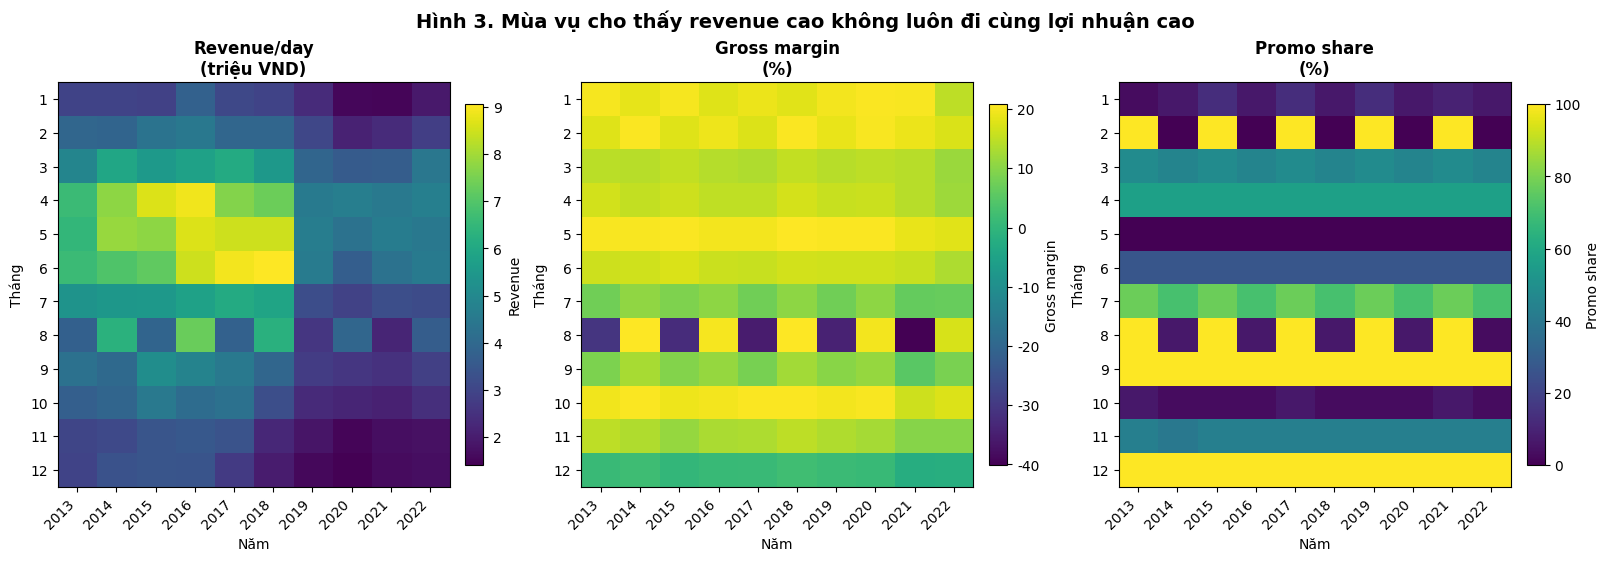

In [22]:

def monthly_year_pivot(value_col):
    tmp = (
        df_funnel
        .groupby(["year", "month"])
        .agg(value=(value_col, "mean"))
        .reset_index()
    )
    return tmp.pivot(index="month", columns="year", values="value")

rev_pivot = monthly_year_pivot("Revenue") / 1_000_000

gm_tmp = (
    df_funnel.groupby(["year", "month"])
    .agg(revenue=("Revenue", "sum"), gross_profit=("gross_profit", "sum"))
    .reset_index()
)
gm_tmp["gross_margin"] = gm_tmp["gross_profit"] / gm_tmp["revenue"]
gm_pivot = gm_tmp.pivot(index="month", columns="year", values="gross_margin") * 100

promo_pivot = (
    df_funnel.groupby(["year", "month"])["is_promo_day"].mean()
    .reset_index()
    .pivot(index="month", columns="year", values="is_promo_day") * 100
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

panels = [
    (rev_pivot, "Revenue/day\n(triệu VND)", "Revenue"),
    (gm_pivot, "Gross margin\n(%)", "Gross margin"),
    (promo_pivot, "Promo share\n(%)", "Promo share"),
]

for ax, (mat, title, label) in zip(axes, panels):
    im = ax.imshow(mat.values, aspect="auto")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Năm")
    ax.set_ylabel("Tháng")
    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_yticklabels(mat.index)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(label)

fig.suptitle("Hình 3. Mùa vụ cho thấy revenue cao không luôn đi cùng lợi nhuận cao", fontsize=14, fontweight="bold")
fig.savefig(FIG_DIR / "fig03_seasonality_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig03_seasonality_heatmaps.svg", bbox_inches="tight")
plt.show()



## 8. Hình 4 và Hình 7 — Chu kỳ trong tháng

Đây là phần kiểm chứng insight cuối tháng: revenue tăng mạnh chủ yếu do conversion tăng, không phải do sessions tăng.


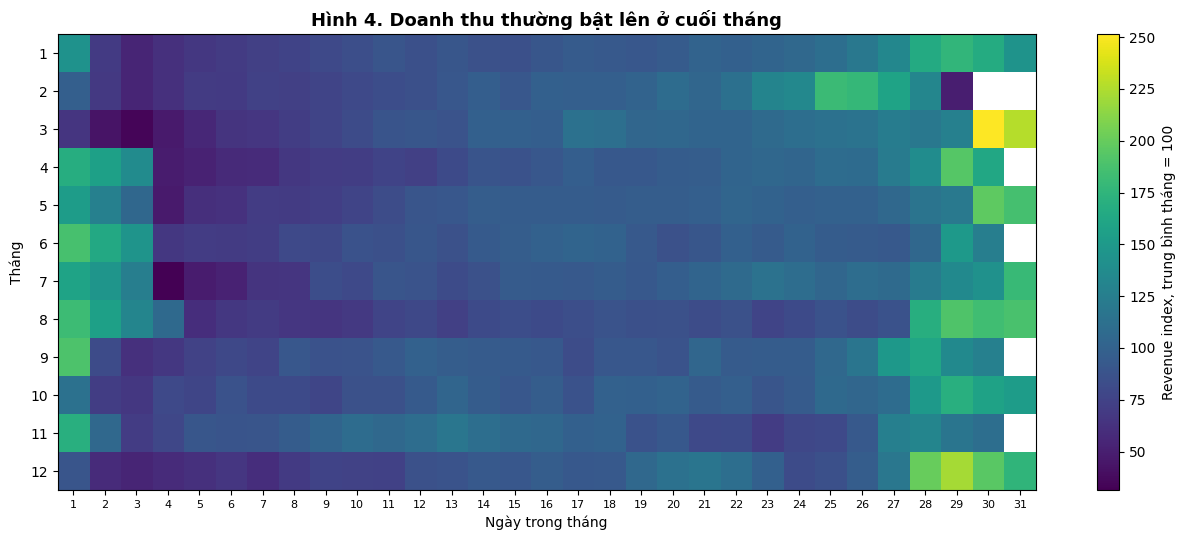

In [23]:

# ============================================================
# 8. Day-of-month effect
# ============================================================
dom = df_funnel.copy()
dom["month_mean_revenue"] = dom.groupby(["year", "month"])["Revenue"].transform("mean")
dom["revenue_index_vs_month"] = dom["Revenue"] / dom["month_mean_revenue"] * 100

dom_pivot = (
    dom.groupby(["month", "day"])["revenue_index_vs_month"]
    .mean()
    .reset_index()
    .pivot(index="month", columns="day", values="revenue_index_vs_month")
)

fig, ax = plt.subplots(figsize=(13, 5.5))
im = ax.imshow(dom_pivot.values, aspect="auto")
ax.set_title("Hình 4. Doanh thu thường bật lên ở cuối tháng", fontsize=13, fontweight="bold")
ax.set_xlabel("Ngày trong tháng")
ax.set_ylabel("Tháng")
ax.set_xticks(np.arange(len(dom_pivot.columns)))
ax.set_xticklabels(dom_pivot.columns, fontsize=8)
ax.set_yticks(np.arange(len(dom_pivot.index)))
ax.set_yticklabels(dom_pivot.index)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Revenue index, trung bình tháng = 100")
fig.tight_layout()

fig.savefig(FIG_DIR / "fig04_day_of_month_heatmap.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig04_day_of_month_heatmap.svg", bbox_inches="tight")
plt.show()

dom_pivot.to_csv(TABLE_DIR / "fig04_day_of_month_heatmap_data.csv")


In [24]:

# ============================================================
# Month position summary: đầu tháng / giữa tháng / cuối tháng
# ============================================================
def month_position(day):
    if day <= 3:
        return "Đầu tháng (1–3)"
    if day >= 28:
        return "Cuối tháng (28–31)"
    return "Giữa tháng (4–27)"

df_funnel["month_position"] = df_funnel["day"].apply(month_position)

month_position_summary = (
    df_funnel.groupby("month_position")
    .agg(
        n_days=("Date", "size"),
        sessions_per_day=("sessions", "mean"),
        orders_per_day=("order_count", "mean"),
        revenue_per_day=("Revenue", "mean"),
        gross_profit_per_day=("gross_profit", "mean"),
        revenue_total=("Revenue", "sum"),
        orders_total=("order_count", "sum"),
        sessions_total=("sessions", "sum"),
        gross_profit_total=("gross_profit", "sum"),
        promo_share=("is_promo_day", "mean"),
    )
    .reset_index()
)

month_position_summary["conversion"] = month_position_summary["orders_total"] / month_position_summary["sessions_total"]
month_position_summary["AOV"] = month_position_summary["revenue_total"] / month_position_summary["orders_total"]
month_position_summary["gross_margin"] = month_position_summary["gross_profit_total"] / month_position_summary["revenue_total"]

order = ["Đầu tháng (1–3)", "Giữa tháng (4–27)", "Cuối tháng (28–31)"]
month_position_summary["month_position"] = pd.Categorical(month_position_summary["month_position"], order, ordered=True)
month_position_summary = month_position_summary.sort_values("month_position")

display(month_position_summary)
month_position_summary.to_csv(TABLE_DIR / "month_position_summary.csv", index=False)

mid = month_position_summary.loc[month_position_summary["month_position"] == "Giữa tháng (4–27)"].iloc[0]
end = month_position_summary.loc[month_position_summary["month_position"] == "Cuối tháng (28–31)"].iloc[0]
start = month_position_summary.loc[month_position_summary["month_position"] == "Đầu tháng (1–3)"].iloc[0]

assert np.isclose(end["revenue_per_day"] / mid["revenue_per_day"] - 1, 0.771, atol=0.005)
assert np.isclose(end["conversion"] / mid["conversion"] - 1, 0.912, atol=0.005)
assert np.isclose(end["sessions_per_day"], mid["sessions_per_day"], atol=5)

month_position_report_values = pd.DataFrame([
    {"item": "Cuối tháng revenue/day uplift vs giữa tháng", "value": end["revenue_per_day"] / mid["revenue_per_day"] - 1, "report_format": f"{(end['revenue_per_day'] / mid['revenue_per_day'] - 1)*100:.1f}%"},
    {"item": "Cuối tháng conversion uplift vs giữa tháng", "value": end["conversion"] / mid["conversion"] - 1, "report_format": f"{(end['conversion'] / mid['conversion'] - 1)*100:.1f}%"},
    {"item": "Cuối tháng sessions/day chênh lệch tuyệt đối", "value": end["sessions_per_day"] - mid["sessions_per_day"], "report_format": f"{end['sessions_per_day'] - mid['sessions_per_day']:.1f} sessions/ngày"},
    {"item": "Cuối tháng AOV change vs giữa tháng", "value": end["AOV"] / mid["AOV"] - 1, "report_format": f"{(end['AOV'] / mid['AOV'] - 1)*100:.1f}%"},
])
display(month_position_report_values)
month_position_report_values.to_csv(TABLE_DIR / "month_position_report_values.csv", index=False)

print("Các số cuối tháng đã được tính trực tiếp từ file daily_table đang dùng.")


,month_position,n_days,sessions_per_day,orders_per_day,revenue_per_day,gross_profit_per_day,revenue_total,orders_total,sessions_total,gross_profit_total,promo_share,conversion,AOV,gross_margin
2,Đầu tháng (1–3),360,24958.955556,205.247222,5.133255e+06,618183.375111,1.847972e+09,73889,8985224.0,2.225460e+08,0.513889,0.008223,25010.106889,0.120427
1,Giữa tháng (4–27),2880,25050.548611,147.499306,3.834648e+06,542408.386753,1.104379e+10,424798,72145580.0,1.562136e+09,0.451042,0.005888,25997.738873,0.141449
0,Cuối tháng (28–31),412,25052.750000,282.055825,6.789368e+06,796864.255485,2.797220e+09,116207,10321733.0,3.283081e+08,0.541262,0.011258,24071.007529,0.117369


,item,value,report_format
0,Cuối tháng revenue/day uplift vs giữa tháng,0.770532,77.1%
1,Cuối tháng conversion uplift vs giữa tháng,0.912084,91.2%
2,Cuối tháng sessions/day chênh lệch tuyệt đối,2.201389,2.2 sessions/ngày
3,Cuối tháng AOV change vs giữa tháng,-0.074111,-7.4%


Các số cuối tháng đã được tính trực tiếp từ file daily_table đang dùng.


,metric,Giữa tháng = 100,Cuối tháng
0,Sessions,100,100.008788
1,Conversion,100,191.208386
2,Orders,100,191.225189
3,Revenue,100,177.053204
4,AOV,100,92.588850
5,Gross margin,100,82.976318


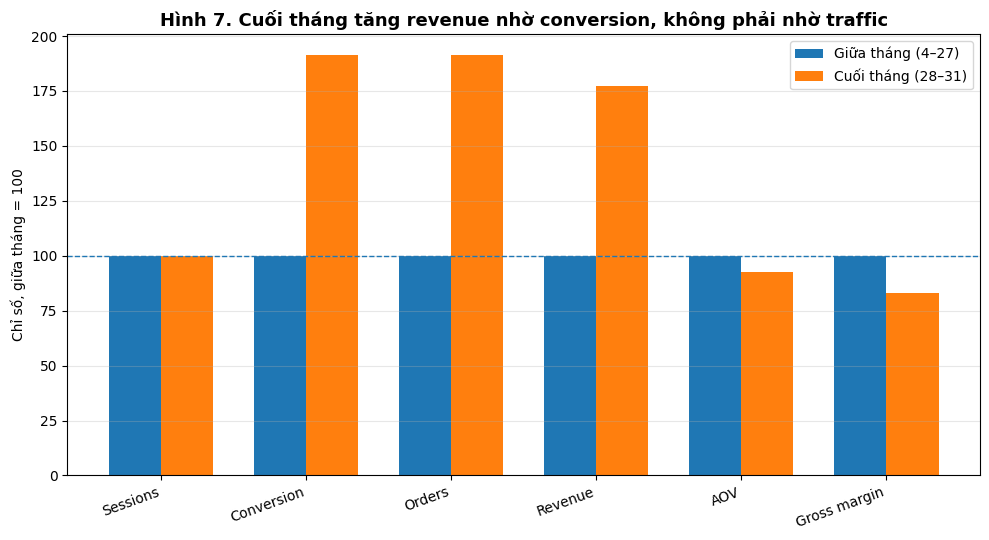

In [25]:

# ============================================================
# Hình 7: Cuối tháng vs giữa tháng index chart
# ============================================================
metrics = {
    "Sessions": "sessions_per_day",
    "Conversion": "conversion",
    "Orders": "orders_per_day",
    "Revenue": "revenue_per_day",
    "AOV": "AOV",
    "Gross margin": "gross_margin",
}

index_values = []
for label, col in metrics.items():
    index_values.append({
        "metric": label,
        "Giữa tháng = 100": 100,
        "Cuối tháng": end[col] / mid[col] * 100,
    })

month_end_index = pd.DataFrame(index_values)
display(month_end_index)
month_end_index.to_csv(TABLE_DIR / "fig07_month_end_index_data.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(month_end_index))
width = 0.36

ax.bar(x - width/2, month_end_index["Giữa tháng = 100"], width, label="Giữa tháng (4–27)")
ax.bar(x + width/2, month_end_index["Cuối tháng"], width, label="Cuối tháng (28–31)")

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(month_end_index["metric"], rotation=20, ha="right")
ax.set_ylabel("Chỉ số, giữa tháng = 100")
ax.set_title("Hình 7. Cuối tháng tăng revenue nhờ conversion, không phải nhờ traffic", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig07_month_end_vs_mid_month.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig07_month_end_vs_mid_month.svg", bbox_inches="tight")
plt.show()



## 9. Hình 5 — Promo vs non-promo

Phần này kiểm chứng trade-off của khuyến mại: promo tăng đơn và conversion, nhưng làm co AOV và làm mỏng gross margin.


In [26]:

promo_summary = (
    df_funnel.groupby("is_promo_day")
    .agg(
        n_days=("Date", "size"),
        sessions_per_day=("sessions", "mean"),
        orders_per_day=("order_count", "mean"),
        revenue_per_day=("Revenue", "mean"),
        gross_profit_per_day=("gross_profit", "mean"),
        revenue_total=("Revenue", "sum"),
        orders_total=("order_count", "sum"),
        sessions_total=("sessions", "sum"),
        gross_profit_total=("gross_profit", "sum"),
    )
    .reset_index()
)

promo_summary["label"] = promo_summary["is_promo_day"].map({0: "Không promo", 1: "Có promo"})
promo_summary["conversion"] = promo_summary["orders_total"] / promo_summary["sessions_total"]
promo_summary["AOV"] = promo_summary["revenue_total"] / promo_summary["orders_total"]
promo_summary["gross_margin"] = promo_summary["gross_profit_total"] / promo_summary["revenue_total"]

display(promo_summary)
promo_summary.to_csv(TABLE_DIR / "promo_vs_nonpromo.csv", index=False)

nonpromo = promo_summary.loc[promo_summary["is_promo_day"] == 0].iloc[0]
promo = promo_summary.loc[promo_summary["is_promo_day"] == 1].iloc[0]

promo_checks = {
    "orders_per_day_change": promo["orders_per_day"] / nonpromo["orders_per_day"] - 1,
    "conversion_change": promo["conversion"] / nonpromo["conversion"] - 1,
    "revenue_per_day_change": promo["revenue_per_day"] / nonpromo["revenue_per_day"] - 1,
    "AOV_change": promo["AOV"] / nonpromo["AOV"] - 1,
    "gross_margin_point_change": promo["gross_margin"] - nonpromo["gross_margin"],
    "gross_profit_per_day_change": promo["gross_profit_per_day"] / nonpromo["gross_profit_per_day"] - 1,
}

display(pd.DataFrame([promo_checks]))
pd.DataFrame([promo_checks]).to_csv(TABLE_DIR / "promo_effect_checks.csv", index=False)

# Kiểm tra theo đúng file daily_table đang dùng.
assert np.isclose(promo_checks["orders_per_day_change"], 0.085, atol=0.003)
assert np.isclose(promo_checks["conversion_change"], 0.121, atol=0.003)
assert np.isclose(promo_checks["revenue_per_day_change"], -0.126, atol=0.003)
assert np.isclose(promo_checks["AOV_change"], -0.194, atol=0.003)
assert np.isclose(promo_checks["gross_margin_point_change"], -0.147, atol=0.003)

promo_report_values = pd.DataFrame([
    {"item": "Orders/day change, promo vs non-promo", "value": promo_checks["orders_per_day_change"], "report_format": f"{promo_checks['orders_per_day_change']*100:.1f}%"},
    {"item": "Conversion change, promo vs non-promo", "value": promo_checks["conversion_change"], "report_format": f"{promo_checks['conversion_change']*100:.1f}%"},
    {"item": "Revenue/day change, promo vs non-promo", "value": promo_checks["revenue_per_day_change"], "report_format": f"{promo_checks['revenue_per_day_change']*100:.1f}%"},
    {"item": "AOV change, promo vs non-promo", "value": promo_checks["AOV_change"], "report_format": f"{promo_checks['AOV_change']*100:.1f}%"},
    {"item": "Gross margin point change", "value": promo_checks["gross_margin_point_change"], "report_format": f"{promo_checks['gross_margin_point_change']*100:.1f} điểm %"},
    {"item": "Gross profit/day change", "value": promo_checks["gross_profit_per_day_change"], "report_format": f"{promo_checks['gross_profit_per_day_change']*100:.1f}%"},
])
display(promo_report_values)
promo_report_values.to_csv(TABLE_DIR / "promo_report_values.csv", index=False)

print("Các số promo đã được tính trực tiếp từ file daily_table đang dùng.")


,is_promo_day,n_days,sessions_per_day,orders_per_day,revenue_per_day,gross_profit_per_day,revenue_total,orders_total,sessions_total,gross_profit_total,label,conversion,AOV,gross_margin
0,0,1945,25424.157326,161.936247,4.563857e+06,906631.112324,8.876702e+09,314966,49449986.0,1.763398e+09,Không promo,0.006369,28183.047251,0.198655
1,1,1707,24606.063855,175.704745,3.990789e+06,204799.489561,6.812277e+09,299928,42002551.0,3.495927e+08,Có promo,0.007141,22713.041720,0.051318


,orders_per_day_change,conversion_change,revenue_per_day_change,AOV_change,gross_margin_point_change,gross_profit_per_day_change
0,0.085024,0.121099,-0.125567,-0.194089,-0.147337,-0.774109


,item,value,report_format
0,"Orders/day change, promo vs non-promo",0.085024,8.5%
1,"Conversion change, promo vs non-promo",0.121099,12.1%
2,"Revenue/day change, promo vs non-promo",-0.125567,-12.6%
3,"AOV change, promo vs non-promo",-0.194089,-19.4%
4,Gross margin point change,-0.147337,-14.7 điểm %
5,Gross profit/day change,-0.774109,-77.4%


Các số promo đã được tính trực tiếp từ file daily_table đang dùng.


,metric,Không promo = 100,Có promo
0,Orders/day,100,108.502419
1,Conversion,100,112.109868
2,Revenue/day,100,87.443347
3,AOV,100,80.591149
4,Gross margin,100,25.832800
5,Gross profit/day,100,22.589065


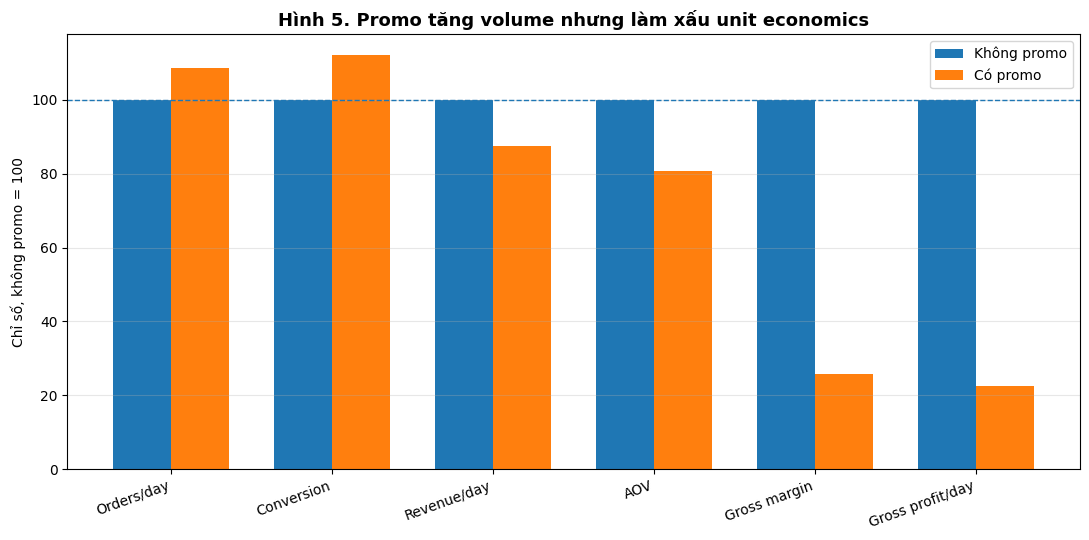

In [27]:

promo_metrics = {
    "Orders/day": "orders_per_day",
    "Conversion": "conversion",
    "Revenue/day": "revenue_per_day",
    "AOV": "AOV",
    "Gross margin": "gross_margin",
    "Gross profit/day": "gross_profit_per_day",
}

promo_index = []
for label, col in promo_metrics.items():
    promo_index.append({
        "metric": label,
        "Không promo = 100": 100,
        "Có promo": promo[col] / nonpromo[col] * 100,
    })

promo_index = pd.DataFrame(promo_index)
display(promo_index)
promo_index.to_csv(TABLE_DIR / "fig05_promo_index_data.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(promo_index))
width = 0.36

ax.bar(x - width/2, promo_index["Không promo = 100"], width, label="Không promo")
ax.bar(x + width/2, promo_index["Có promo"], width, label="Có promo")

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(promo_index["metric"], rotation=20, ha="right")
ax.set_ylabel("Chỉ số, không promo = 100")
ax.set_title("Hình 5. Promo tăng volume nhưng làm xấu unit economics", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig05_promo_vs_nonpromo.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig05_promo_vs_nonpromo.svg", bbox_inches="tight")
plt.show()



## 10. Hình 6 — Weekday vs weekend

Phần này kiểm chứng rằng cuối tuần thấp hơn chủ yếu do conversion, không phải do traffic hoặc AOV.


In [28]:

weekday_summary = (
    df_funnel.groupby("is_weekend")
    .agg(
        n_days=("Date", "size"),
        sessions_per_day=("sessions", "mean"),
        orders_per_day=("order_count", "mean"),
        revenue_per_day=("Revenue", "mean"),
        revenue_total=("Revenue", "sum"),
        orders_total=("order_count", "sum"),
        sessions_total=("sessions", "sum"),
        gross_profit_total=("gross_profit", "sum"),
    )
    .reset_index()
)

weekday_summary["label"] = weekday_summary["is_weekend"].map({0: "Ngày thường", 1: "Cuối tuần"})
weekday_summary["conversion"] = weekday_summary["orders_total"] / weekday_summary["sessions_total"]
weekday_summary["AOV"] = weekday_summary["revenue_total"] / weekday_summary["orders_total"]
weekday_summary["gross_margin"] = weekday_summary["gross_profit_total"] / weekday_summary["revenue_total"]

display(weekday_summary)
weekday_summary.to_csv(TABLE_DIR / "weekday_vs_weekend.csv", index=False)

weekday = weekday_summary.loc[weekday_summary["is_weekend"] == 0].iloc[0]
weekend = weekday_summary.loc[weekday_summary["is_weekend"] == 1].iloc[0]

weekday_checks = {
    "sessions_change_weekend": weekend["sessions_per_day"] / weekday["sessions_per_day"] - 1,
    "conversion_change_weekend": weekend["conversion"] / weekday["conversion"] - 1,
    "AOV_change_weekend": weekend["AOV"] / weekday["AOV"] - 1,
    "revenue_change_weekend": weekend["revenue_per_day"] / weekday["revenue_per_day"] - 1,
}

display(pd.DataFrame([weekday_checks]))
pd.DataFrame([weekday_checks]).to_csv(TABLE_DIR / "weekday_weekend_checks.csv", index=False)

# Kiểm tra theo đúng file daily_table đang dùng.
assert np.isclose(weekday_checks["revenue_change_weekend"], -0.092, atol=0.003)
assert np.isclose(weekday_checks["sessions_change_weekend"], -0.003, atol=0.003)
assert np.isclose(weekday_checks["AOV_change_weekend"], 0.000, atol=0.003)
assert np.isclose(weekday_checks["conversion_change_weekend"], -0.089, atol=0.003)

weekday_report_values = pd.DataFrame([
    {"item": "Weekend revenue/day change vs weekday", "value": weekday_checks["revenue_change_weekend"], "report_format": f"{weekday_checks['revenue_change_weekend']*100:.1f}%"},
    {"item": "Weekend sessions/day change vs weekday", "value": weekday_checks["sessions_change_weekend"], "report_format": f"{weekday_checks['sessions_change_weekend']*100:.1f}%"},
    {"item": "Weekend conversion change vs weekday", "value": weekday_checks["conversion_change_weekend"], "report_format": f"{weekday_checks['conversion_change_weekend']*100:.1f}%"},
    {"item": "Weekend AOV change vs weekday", "value": weekday_checks["AOV_change_weekend"], "report_format": f"{weekday_checks['AOV_change_weekend']*100:.1f}%"},
])
display(weekday_report_values)
weekday_report_values.to_csv(TABLE_DIR / "weekday_report_values.csv", index=False)

print("Các số weekday/weekend đã được tính trực tiếp từ file daily_table đang dùng.")


,is_weekend,n_days,sessions_per_day,orders_per_day,revenue_per_day,revenue_total,orders_total,sessions_total,gross_profit_total,label,conversion,AOV,gross_margin
0,0,2609,25063.933308,172.900345,4.411533e+06,1.150969e+10,451097,65391802.0,1.551663e+09,Ngày thường,0.006898,25514.890853,0.134814
1,1,1043,24986.323106,157.044104,4.006988e+06,4.179288e+09,163797,26060735.0,5.613276e+08,Cuối tuần,0.006285,25515.046787,0.134312


,sessions_change_weekend,conversion_change_weekend,AOV_change_weekend,revenue_change_weekend
0,-0.003096,-0.088886,0.000006,-0.091702


,item,value,report_format
0,Weekend revenue/day change vs weekday,-0.091702,-9.2%
1,Weekend sessions/day change vs weekday,-0.003096,-0.3%
2,Weekend conversion change vs weekday,-0.088886,-8.9%
3,Weekend AOV change vs weekday,0.000006,0.0%


Các số weekday/weekend đã được tính trực tiếp từ file daily_table đang dùng.


,metric,Ngày thường = 100,Cuối tuần
0,Sessions,100,99.690351
1,Conversion,100,91.111385
2,Orders,100,90.829260
3,Revenue,100,90.829815
4,AOV,100,100.000611
5,Gross margin,100,99.627785


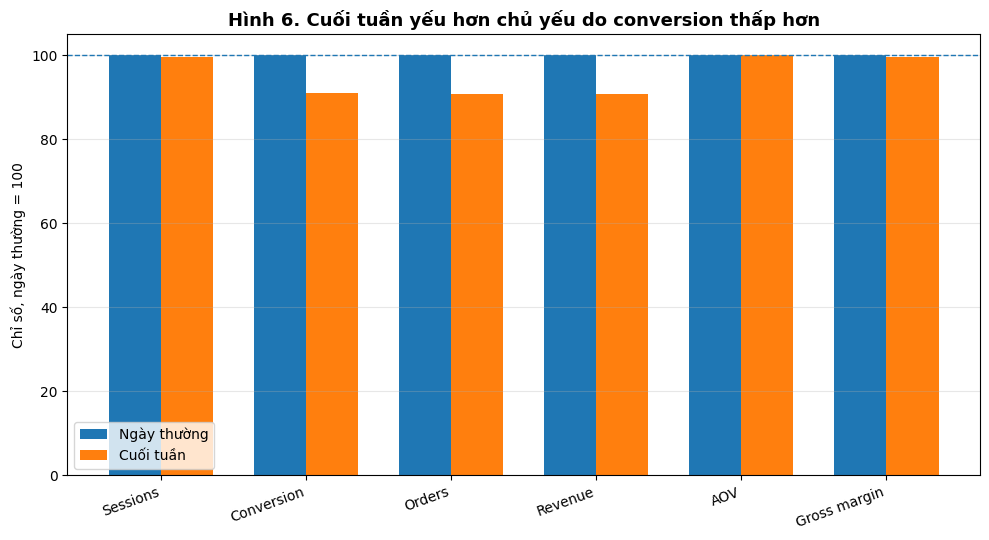

In [29]:

ww_metrics = {
    "Sessions": "sessions_per_day",
    "Conversion": "conversion",
    "Orders": "orders_per_day",
    "Revenue": "revenue_per_day",
    "AOV": "AOV",
    "Gross margin": "gross_margin",
}

ww_index = []
for label, col in ww_metrics.items():
    ww_index.append({
        "metric": label,
        "Ngày thường = 100": 100,
        "Cuối tuần": weekend[col] / weekday[col] * 100,
    })

ww_index = pd.DataFrame(ww_index)
display(ww_index)
ww_index.to_csv(TABLE_DIR / "fig06_weekday_weekend_index_data.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(ww_index))
width = 0.36

ax.bar(x - width/2, ww_index["Ngày thường = 100"], width, label="Ngày thường")
ax.bar(x + width/2, ww_index["Cuối tuần"], width, label="Cuối tuần")

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(ww_index["metric"], rotation=20, ha="right")
ax.set_ylabel("Chỉ số, ngày thường = 100")
ax.set_title("Hình 6. Cuối tuần yếu hơn chủ yếu do conversion thấp hơn", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig06_weekday_vs_weekend.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig06_weekday_vs_weekend.svg", bbox_inches="tight")
plt.show()



## 11. Hình 8 — Scenario analysis theo conversion

Phần này tạo bảng kịch bản trong báo cáo: giữ nguyên sessions và AOV năm 2022, chỉ thay conversion.


In [30]:

sessions_2022 = yearly.loc[yearly["year"] == 2022, "sessions_total"].iloc[0]
aov_2022 = yearly.loc[yearly["year"] == 2022, "AOV"].iloc[0]
revenue_2022 = yearly.loc[yearly["year"] == 2022, "revenue_total"].iloc[0]
conversion_2022 = yearly.loc[yearly["year"] == 2022, "conversion"].iloc[0]

target_conversions = [conversion_2022, 0.0040, 0.0050]
scenario = pd.DataFrame({"conversion": target_conversions})
scenario["orders_est"] = scenario["conversion"] * sessions_2022
scenario["revenue_est"] = scenario["orders_est"] * aov_2022
scenario["uplift_vnd"] = scenario["revenue_est"] - revenue_2022
scenario["uplift_pct"] = scenario["uplift_vnd"] / revenue_2022
scenario["label"] = ["Thực tế 2022", "CVR 0,40%", "CVR 0,50%"]

display(scenario)
scenario.to_csv(TABLE_DIR / "scenario_forecast.csv", index=False)

assert np.isclose(scenario.loc[1, "revenue_est"] / 1_000_000_000, 1.438, atol=0.002)
assert np.isclose(scenario.loc[1, "uplift_vnd"] / 1_000_000, 268.1, atol=1.0)
assert np.isclose(scenario.loc[1, "uplift_pct"], 0.229, atol=0.002)
assert np.isclose(scenario.loc[2, "revenue_est"] / 1_000_000_000, 1.797, atol=0.002)
assert np.isclose(scenario.loc[2, "uplift_vnd"] / 1_000_000, 627.5, atol=1.0)
assert np.isclose(scenario.loc[2, "uplift_pct"], 0.536, atol=0.002)

print("✅ Các số scenario khớp với báo cáo.")


,conversion,orders_est,revenue_est,uplift_vnd,uplift_pct,label
0,0.003254,36004.000,1.169749e+09,0.000000e+00,0.000000,Thực tế 2022
1,0.004000,44254.632,1.437807e+09,2.680582e+08,0.229159,"CVR 0,40%"
2,0.005000,55318.290,1.797259e+09,6.275099e+08,0.536448,"CVR 0,50%"


✅ Các số scenario khớp với báo cáo.


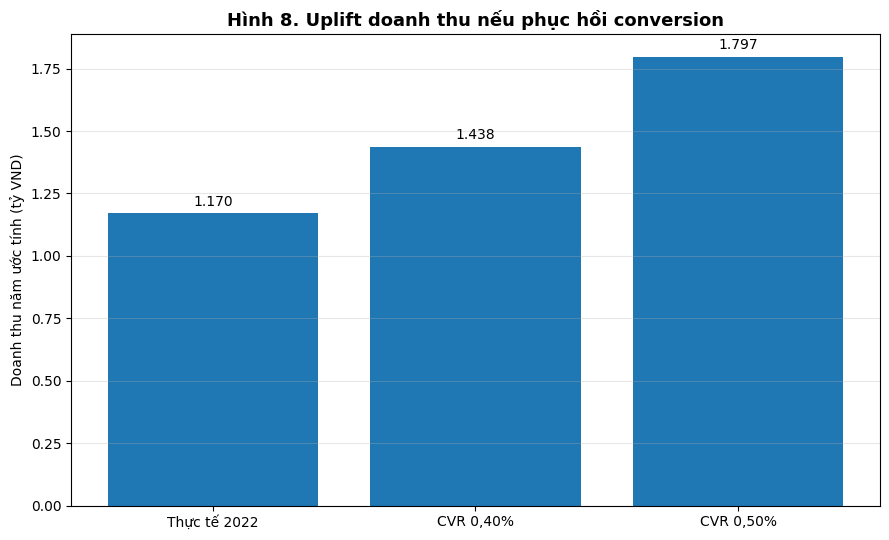

In [31]:

# ============================================================
# Hình 8: Scenario chart
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(scenario["label"], scenario["revenue_est"] / 1_000_000_000)
ax.set_ylabel("Doanh thu năm ước tính (tỷ VND)")
ax.set_title("Hình 8. Uplift doanh thu nếu phục hồi conversion", fontsize=13, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)

for i, row in scenario.iterrows():
    ax.text(i, row["revenue_est"] / 1_000_000_000 + 0.03, f"{row['revenue_est']/1_000_000_000:.3f}", ha="center")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig08_conversion_scenario.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig08_conversion_scenario.svg", bbox_inches="tight")
plt.show()



## 12. Regression phụ trợ cho promo

Phần này không dùng để kết luận nhân quả tuyệt đối. Mục đích là kiểm tra mối liên hệ giữa ngày promo và các chỉ số chính sau khi kiểm soát năm, tháng và ngày trong tuần.

Mô hình đơn giản:

`log(metric) ~ is_promo_day + C(year) + C(month) + C(weekday_number)`

Với `gross_margin`, dùng mô hình tuyến tính trực tiếp vì đây đã là tỷ lệ.


In [32]:

try:
    import statsmodels.formula.api as smf

    reg_df = df_funnel.copy()
    # Tránh log(0)
    reg_df = reg_df[(reg_df["order_count"] > 0) & (reg_df["Revenue"] > 0) & (reg_df["AOV"] > 0)].copy()

    reg_df["log_orders"] = np.log(reg_df["order_count"])
    reg_df["log_revenue"] = np.log(reg_df["Revenue"])
    reg_df["log_AOV"] = np.log(reg_df["AOV"])

    models = {
        "orders_pct": smf.ols("log_orders ~ is_promo_day + C(year) + C(month) + C(weekday_number)", data=reg_df).fit(),
        "AOV_pct": smf.ols("log_AOV ~ is_promo_day + C(year) + C(month) + C(weekday_number)", data=reg_df).fit(),
        "revenue_pct": smf.ols("log_revenue ~ is_promo_day + C(year) + C(month) + C(weekday_number)", data=reg_df).fit(),
        "gross_margin_point": smf.ols("gross_margin ~ is_promo_day + C(year) + C(month) + C(weekday_number)", data=reg_df).fit(),
    }

    reg_results = []
    for name, model in models.items():
        coef = model.params["is_promo_day"]
        if name.endswith("_pct"):
            effect = np.exp(coef) - 1
        else:
            effect = coef
        reg_results.append({
            "metric": name,
            "promo_effect": effect,
            "p_value": model.pvalues["is_promo_day"],
            "r2": model.rsquared,
        })

    promo_regression_effects = pd.DataFrame(reg_results)
    display(promo_regression_effects)
    promo_regression_effects.to_csv(TABLE_DIR / "promo_regression_effects.csv", index=False)

except Exception as e:
    print("Không chạy được statsmodels trong môi trường hiện tại. Phần này là phụ trợ, các bảng chính phía trên vẫn tái lập đầy đủ.")
    print("Error:", repr(e))


,metric,promo_effect,p_value,r2
0,orders_pct,0.183367,1.263176e-20,0.613274
1,AOV_pct,-0.178109,4.768360e-245,0.724808
2,revenue_pct,-0.027401,1.127350e-01,0.574003
3,gross_margin_point,-0.160019,0.000000e+00,0.667832



## 13. Tổng hợp file đã xuất

Sau khi chạy notebook, toàn bộ bảng CSV và hình PNG/SVG nằm trong `outputs_part2/`.

Các file hình chính:

1. `fig01_yearly_index.png`
2. `fig02_revenue_waterfall.png`
3. `fig03_seasonality_heatmaps.png`
4. `fig04_day_of_month_heatmap.png`
5. `fig05_promo_vs_nonpromo.png`
6. `fig06_weekday_vs_weekend.png`
7. `fig07_month_end_vs_mid_month.png`
8. `fig08_conversion_scenario.png`

Các file này có thể chèn vào LaTeX bằng:

```latex
\includegraphics[width=0.9\textwidth]{outputs_part2/figures/fig01_yearly_index.png}
```


In [33]:

print("Figures:")
for p in sorted(FIG_DIR.glob("*")):
    print(" -", p)

print("\nTables:")
for p in sorted(TABLE_DIR.glob("*")):
    print(" -", p)


Figures:
 - outputs_part2/figures/fig01_yearly_index.png
 - outputs_part2/figures/fig01_yearly_index.svg
 - outputs_part2/figures/fig02_revenue_waterfall.png
 - outputs_part2/figures/fig02_revenue_waterfall.svg
 - outputs_part2/figures/fig03_seasonality_heatmaps.png
 - outputs_part2/figures/fig03_seasonality_heatmaps.svg
 - outputs_part2/figures/fig04_day_of_month_heatmap.png
 - outputs_part2/figures/fig04_day_of_month_heatmap.svg
 - outputs_part2/figures/fig05_promo_vs_nonpromo.png
 - outputs_part2/figures/fig05_promo_vs_nonpromo.svg
 - outputs_part2/figures/fig06_weekday_vs_weekend.png
 - outputs_part2/figures/fig06_weekday_vs_weekend.svg
 - outputs_part2/figures/fig07_month_end_vs_mid_month.png
 - outputs_part2/figures/fig07_month_end_vs_mid_month.svg
 - outputs_part2/figures/fig08_conversion_scenario.png
 - outputs_part2/figures/fig08_conversion_scenario.svg

Tables:
 - outputs_part2/tables/2018_2022_key_changes.csv
 - outputs_part2/tables/fig01_yearly_index_data.csv
 - outputs_par